In [1]:
# ============================================================
# Predictive-Performance Comparison Across Models
# ----------------------------------------------------------
# Loads the pickled out-of-sample R^2-vs-initial-concentration results
# produced by the CRHM / IRHM-SVD / IRHM-SIMPLISMA / CRMM1 / CRMM2 fitting
# notebooks, reshapes them by (scenario, spectral overlap, inhibition
# strength Ki), and plots them. The first half of the notebook makes
# quick exploratory per-model plots; the second half ("Image Generation
# for manuscript") builds the polished multi-panel comparison figures
# used in the FOCAPO paper (Figures 3-5).
# ============================================================

import os 
import pickle
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

In [2]:
# Must match the initial-Ca sweep used when generating the predictive-
# performance results (see rect_init / C1_range in the modeling notebooks)
# so the x-axis lines up with the loaded R^2 curves.
C1_range = np.logspace(-2, 1,50)

# Coupled Raman Hybird Model

In [3]:
# The three spectral scenarios (A/B/C all Raman-active; B weakly active;
# B Raman-silent) compared throughout this notebook.
scenario_list = ["Scenario 1", "Scenario 2", "Scenario 3"]

In [4]:
# Indexes every saved CRHM (Hybrid model) result file by scenario and
# spectral overlap (0.2 / 0.6), based on the "_<overlap>_" token embedded
# in each pickle's filename.
full_coupled_dict = {}

for j in range(len(scenario_list)):
    
    couple_dir = "Coupled Performance/Hybrid model/" + scenario_list[j] + "/(322)_ANN"
    coupled_list = os.listdir(couple_dir)

    couple_file_dict = {}

    couple_file_dict["0.2"] = []
    couple_file_dict["0.6"] = []

    for i in range(len(coupled_list)):
        if ".pkl" in coupled_list[i]:
            spcovp = coupled_list[i].split("_")[4]
            couple_file_dict[spcovp].append(coupled_list[i])
    
    full_coupled_dict[scenario_list[j]] = couple_file_dict

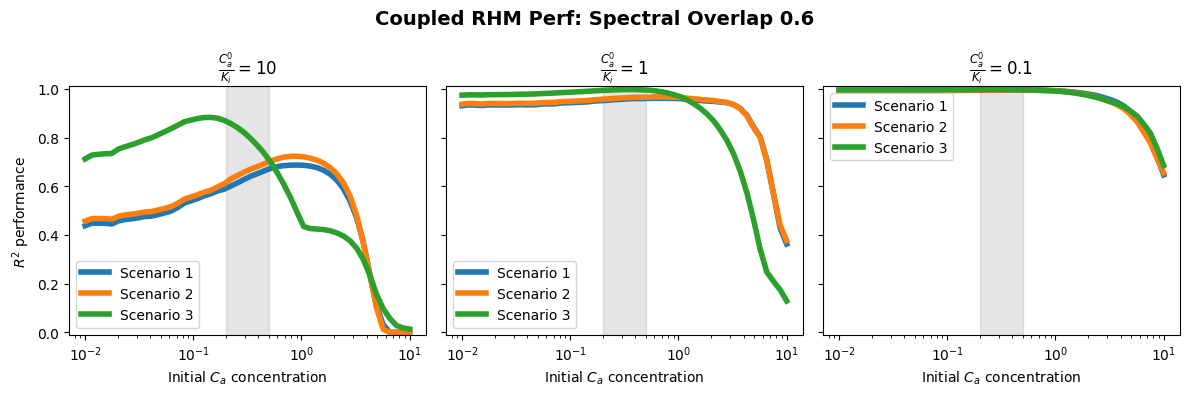

In [5]:
# Exploratory plot: CRHM out-of-sample R^2 vs. initial Ca concentration,
# spectral overlap 0.6, one panel per inhibition-strength regime
# (Ca0/Ki = 10, 1, 0.1 -- inferred from log10(Ki/5) via xind), one line per
# scenario. Averages R^2 across all files sharing the same (Ki1, Ki2).
fig, axs = plt.subplots(1, 3, figsize = (12, 4), sharex = True, sharey = True)

for k in range(len(scenario_list)):
    couple_dir = "Coupled Performance/Hybrid model/" + scenario_list[k] + "/(322)_ANN"
    couple_file_dict = full_coupled_dict[scenario_list[k]]
    
    C6_performance_list = couple_file_dict["0.6"]

    C6_unique_dict = {}
    for i in range(len(C6_performance_list)):
        name = C6_performance_list[i]
        k1 = float(name.split("_")[1])
        k2 = float(name.split("_")[2])
        ky = tuple([k1, k2])

        if ky not in list(C6_unique_dict.keys()):
            C6_unique_dict[ky] = []

        filepath = os.path.join(couple_dir, name)
        with open(filepath, "rb") as f:
            data = np.array(pickle.load(f)["conc_perf"])[:,0]

        C6_unique_dict[ky].append(data)
        
    row_title = [r"$\frac{C_a^0}{K_i} = 10$", r"$\frac{C_a^0}{K_i} = 1$", r"$\frac{C_a^0}{K_i} = 0.1$"]

    for a in list(C6_unique_dict.keys()):
        xind = int(2 + np.log10(a[0]/5))

        data = np.mean(np.array(C6_unique_dict[a]), axis = 0)

        axs[xind].plot(C1_range, data, label = scenario_list[k], linewidth = 4)
        axs[xind].legend()
        axs[xind].set_xscale("log")
        if k == 0:
            axs[xind].axvspan(0.2, 0.5, color = "k", alpha = 0.1)
        axs[xind].set_ylim([-0.01, 1.01])
        axs[xind].set_xlabel("Initial $C_a$ concentration")
        axs[xind].set_title(row_title[xind])
        if xind == 0:
            axs[xind].set_ylabel("$R^2$ performance")
        
fig.suptitle("Coupled RHM Perf: Spectral Overlap 0.6", fontweight = "bold", fontsize = 14)
plt.tight_layout()

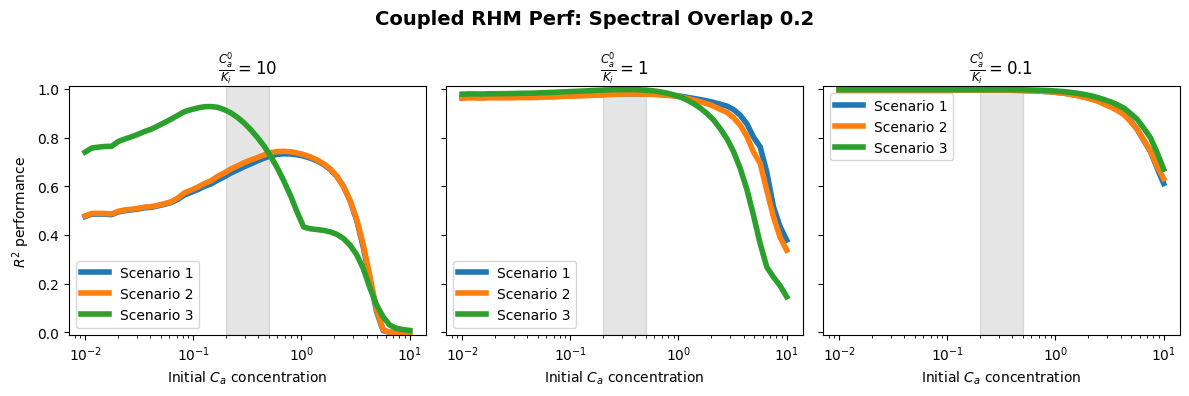

In [6]:
# Same as above, for spectral overlap 0.2.
fig, axs = plt.subplots(1, 3, figsize = (12, 4), sharex = True, sharey = True)

for k in range(len(scenario_list)):
    couple_dir = "Coupled Performance/Hybrid model/" + scenario_list[k] + "/(322)_ANN"
    couple_file_dict = full_coupled_dict[scenario_list[k]]
    
    C2_performance_list = couple_file_dict["0.2"]

    C2_unique_dict = {}
    for i in range(len(C2_performance_list)):
        name = C2_performance_list[i]
        k1 = float(name.split("_")[1])
        k2 = float(name.split("_")[2])
        ky = tuple([k1, k2])

        if ky not in list(C2_unique_dict.keys()):
            C2_unique_dict[ky] = []

        filepath = os.path.join(couple_dir, name)
        with open(filepath, "rb") as f:
            data = np.array(pickle.load(f)["conc_perf"])[:,0]

        C2_unique_dict[ky].append(data)
        
    row_title = [r"$\frac{C_a^0}{K_i} = 10$", r"$\frac{C_a^0}{K_i} = 1$", r"$\frac{C_a^0}{K_i} = 0.1$"]

    for a in list(C2_unique_dict.keys()):
        xind = int(2 + np.log10(a[0]/5))

        data = np.mean(np.array(C2_unique_dict[a]), axis = 0)

        axs[xind].plot(C1_range, data, label = scenario_list[k], linewidth = 4)
        axs[xind].legend()
        axs[xind].set_xscale("log")
        if k == 0:
            axs[xind].axvspan(0.2, 0.5, color = "k", alpha = 0.1)
        axs[xind].set_ylim([-0.01, 1.01])
        axs[xind].set_xlabel("Initial $C_a$ concentration")
        axs[xind].set_title(row_title[xind])
        if xind == 0:
            axs[xind].set_ylabel("$R^2$ performance")
        
fig.suptitle("Coupled RHM Perf: Spectral Overlap 0.2", fontweight = "bold", fontsize = 14)
plt.tight_layout()

# Iterative Raman Hybrid Model - SVD initialization

In [7]:
# Indexes every saved IRHM-SVD result file by scenario and spectral
# overlap, same convention as full_coupled_dict above.
full_iterative_dict = {}

for j in range(len(scenario_list)):
    
    iterative_dir = "Iterative Performance/SVD_init/" + scenario_list[j] + "/(322)_ANN"
    iterative_list = os.listdir(iterative_dir)

    iterative_file_dict = {}

    iterative_file_dict["0.2"] = []
    iterative_file_dict["0.6"] = []

    for i in range(len(iterative_list)):
        if ".pkl" in iterative_list[i]:
            spcovp = iterative_list[i].split("_")[4]
            iterative_file_dict[spcovp].append(iterative_list[i])
    
    full_iterative_dict[scenario_list[j]] = iterative_file_dict

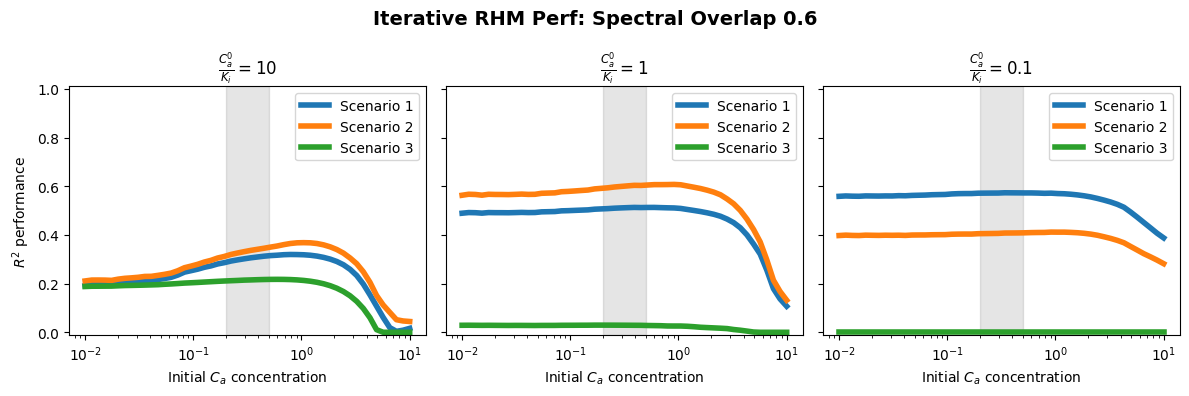

In [8]:
# Exploratory plot: IRHM-SVD out-of-sample R^2 vs. initial Ca
# concentration, spectral overlap 0.6. Scenario 3 results were generated
# on the finer 500-point sweep, so they're downsampled by 10 (data[::10])
# to match the 50-point x-axis (C1_range) used here.
fig, axs = plt.subplots(1, 3, figsize = (12, 4), sharex = True, sharey = True)

for k in range(len(scenario_list)):
    iterative_dir = "Iterative Performance/SVD_init/" + scenario_list[k] + "/(322)_ANN"
    iterative_file_dict = full_iterative_dict[scenario_list[k]]
    
    I6_performance_list = iterative_file_dict["0.6"]

    I6_unique_dict = {}
    for i in range(len(I6_performance_list)):
        name = I6_performance_list[i]
        k1 = float(name.split("_")[1])
        k2 = float(name.split("_")[2])
        ky = tuple([k1, k2])

        if ky not in list(I6_unique_dict.keys()):
            I6_unique_dict[ky] = []

        filepath = os.path.join(iterative_dir, name)
        with open(filepath, "rb") as f:
            data = np.array(pickle.load(f)["conc_perf"])[:,0]

        I6_unique_dict[ky].append(data)
        
    row_title = [r"$\frac{C_a^0}{K_i} = 10$", r"$\frac{C_a^0}{K_i} = 1$", r"$\frac{C_a^0}{K_i} = 0.1$"]

    for a in list(I6_unique_dict.keys()):
        xind = int(2 + np.log10(a[0]/5))

        data = np.mean(np.array(I6_unique_dict[a]), axis = 0)
        if len(data) == 500:
            data = data[::10]

        axs[xind].plot(C1_range, data, label = scenario_list[k], linewidth = 4)
        axs[xind].legend()
        axs[xind].set_xscale("log")
        if k == 0:
            axs[xind].axvspan(0.2, 0.5, color = "k", alpha = 0.1)
        axs[xind].set_ylim([-0.01, 1.01])
        axs[xind].set_xlabel("Initial $C_a$ concentration")
        axs[xind].set_title(row_title[xind])
        if xind == 0:
            axs[xind].set_ylabel("$R^2$ performance")
        
fig.suptitle("Iterative RHM Perf: Spectral Overlap 0.6", fontweight = "bold", fontsize = 14)
plt.tight_layout()

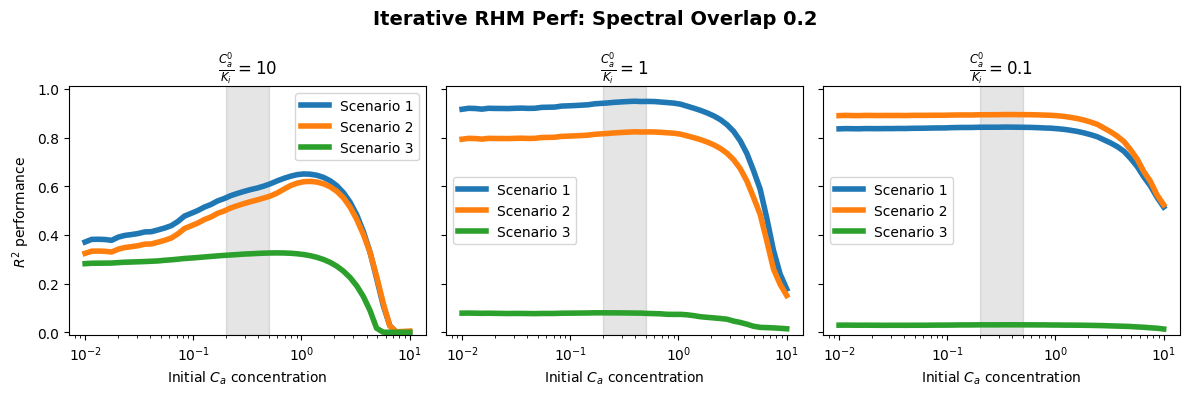

In [9]:
# Same as above, for spectral overlap 0.2.
fig, axs = plt.subplots(1, 3, figsize = (12, 4), sharex = True, sharey = True)

for k in range(len(scenario_list)):
    iterative_dir = "Iterative Performance/SVD_init/" + scenario_list[k] + "/(322)_ANN"
    iterative_file_dict = full_iterative_dict[scenario_list[k]]
    
    I2_performance_list = iterative_file_dict["0.2"]

    I2_unique_dict = {}
    for i in range(len(I2_performance_list)):
        name = I2_performance_list[i]
        k1 = float(name.split("_")[1])
        k2 = float(name.split("_")[2])
        ky = tuple([k1, k2])

        if ky not in list(I2_unique_dict.keys()):
            I2_unique_dict[ky] = []

        filepath = os.path.join(iterative_dir, name)
        with open(filepath, "rb") as f:
            data = np.array(pickle.load(f)["conc_perf"])[:,0]

        I2_unique_dict[ky].append(data)
        
    row_title = [r"$\frac{C_a^0}{K_i} = 10$", r"$\frac{C_a^0}{K_i} = 1$", r"$\frac{C_a^0}{K_i} = 0.1$"]

    for a in list(I2_unique_dict.keys()):
        xind = int(2 + np.log10(a[0]/5))

        data = np.mean(np.array(I2_unique_dict[a]), axis = 0)
        if len(data) == 500:
            data = data[::10]

        axs[xind].plot(C1_range, data, label = scenario_list[k], linewidth = 4)
        axs[xind].legend()
        axs[xind].set_xscale("log")
        if k == 0:
            axs[xind].axvspan(0.2, 0.5, color = "k", alpha = 0.1)
        axs[xind].set_ylim([-0.01, 1.01])
        axs[xind].set_xlabel("Initial $C_a$ concentration")
        axs[xind].set_title(row_title[xind])
        if xind == 0:
            axs[xind].set_ylabel("$R^2$ performance")
        
fig.suptitle("Iterative RHM Perf: Spectral Overlap 0.2", fontweight = "bold", fontsize = 14)
plt.tight_layout()

# Iterative Raman Hybrid Model - SIMPLISMA initialization

In [10]:
# Indexes every saved IRHM-SIMPLISMA result file by scenario and spectral
# overlap (reuses the full_iterative_dict / iterative_dir names from the
# SVD section above, now pointed at the SIMPLISMA_init directory).
full_iterative_dict = {}

for j in range(len(scenario_list)):
    
    iterative_dir = "Iterative Performance/SIMPLISMA_init/" + scenario_list[j] + "/(322)_ANN"
    iterative_list = os.listdir(iterative_dir)

    iterative_file_dict = {}

    iterative_file_dict["0.2"] = []
    iterative_file_dict["0.6"] = []

    for i in range(len(iterative_list)):
        if ".pkl" in iterative_list[i]:
            spcovp = iterative_list[i].split("_")[4]
            iterative_file_dict[spcovp].append(iterative_list[i])
    
    full_iterative_dict[scenario_list[j]] = iterative_file_dict

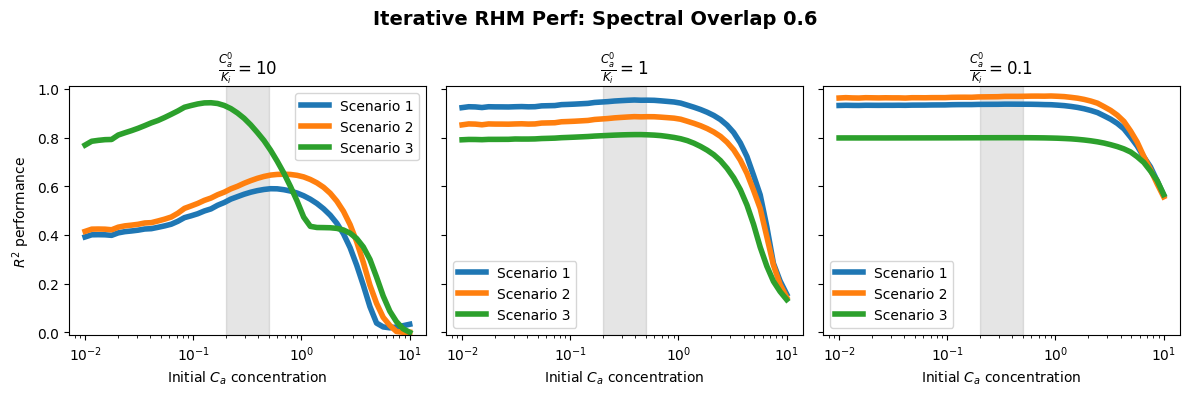

In [11]:
# Exploratory plot: IRHM-SIMPLISMA out-of-sample R^2 vs. initial Ca
# concentration, spectral overlap 0.6 (same 500->50 downsampling as the
# SVD version for Scenario 3).
fig, axs = plt.subplots(1, 3, figsize = (12, 4), sharex = True, sharey = True)

for k in range(len(scenario_list)):
    iterative_dir = "Iterative Performance/SIMPLISMA_init/" + scenario_list[k] + "/(322)_ANN"
    iterative_file_dict = full_iterative_dict[scenario_list[k]]
    
    I6_performance_list = iterative_file_dict["0.6"]

    I6_unique_dict = {}
    for i in range(len(I6_performance_list)):
        name = I6_performance_list[i]
        k1 = float(name.split("_")[1])
        k2 = float(name.split("_")[2])
        ky = tuple([k1, k2])

        if ky not in list(I6_unique_dict.keys()):
            I6_unique_dict[ky] = []

        filepath = os.path.join(iterative_dir, name)
        with open(filepath, "rb") as f:
            data = np.array(pickle.load(f)["conc_perf"])[:,0]

        I6_unique_dict[ky].append(data)
        
    row_title = [r"$\frac{C_a^0}{K_i} = 10$", r"$\frac{C_a^0}{K_i} = 1$", r"$\frac{C_a^0}{K_i} = 0.1$"]

    for a in list(I6_unique_dict.keys()):
        xind = int(2 + np.log10(a[0]/5))

        data = np.mean(np.array(I6_unique_dict[a]), axis = 0)
        if len(data) == 500:
            data = data[::10]

        axs[xind].plot(C1_range, data, label = scenario_list[k], linewidth = 4)
        axs[xind].legend()
        axs[xind].set_xscale("log")
        if k == 0:
            axs[xind].axvspan(0.2, 0.5, color = "k", alpha = 0.1)
        axs[xind].set_ylim([-0.01, 1.01])
        axs[xind].set_xlabel("Initial $C_a$ concentration")
        axs[xind].set_title(row_title[xind])
        if xind == 0:
            axs[xind].set_ylabel("$R^2$ performance")
        
fig.suptitle("Iterative RHM Perf: Spectral Overlap 0.6", fontweight = "bold", fontsize = 14)
plt.tight_layout()

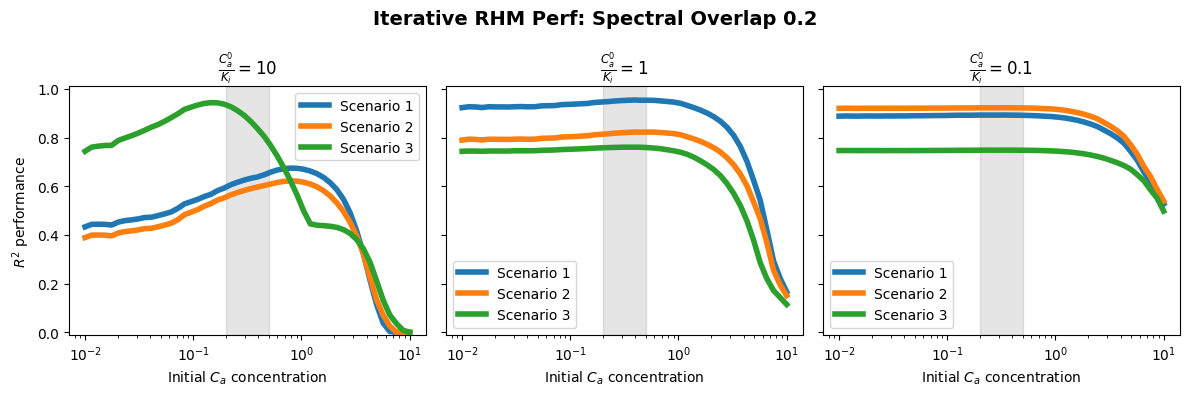

In [12]:
# Same as above, for spectral overlap 0.2.
fig, axs = plt.subplots(1, 3, figsize = (12, 4), sharex = True, sharey = True)

for k in range(len(scenario_list)):
    iterative_dir = "Iterative Performance/SIMPLISMA_init/" + scenario_list[k] + "/(322)_ANN"
    iterative_file_dict = full_iterative_dict[scenario_list[k]]
    
    I2_performance_list = iterative_file_dict["0.2"]

    I2_unique_dict = {}
    for i in range(len(I2_performance_list)):
        name = I2_performance_list[i]
        k1 = float(name.split("_")[1])
        k2 = float(name.split("_")[2])
        ky = tuple([k1, k2])

        if ky not in list(I2_unique_dict.keys()):
            I2_unique_dict[ky] = []

        filepath = os.path.join(iterative_dir, name)
        with open(filepath, "rb") as f:
            data = np.array(pickle.load(f)["conc_perf"])[:,0]

        I2_unique_dict[ky].append(data)
        
    row_title = [r"$\frac{C_a^0}{K_i} = 10$", r"$\frac{C_a^0}{K_i} = 1$", r"$\frac{C_a^0}{K_i} = 0.1$"]

    for a in list(I2_unique_dict.keys()):
        xind = int(2 + np.log10(a[0]/5))

        data = np.mean(np.array(I2_unique_dict[a]), axis = 0)
        if len(data) == 500:
            data = data[::10]

        axs[xind].plot(C1_range, data, label = scenario_list[k], linewidth = 4)
        axs[xind].legend()
        axs[xind].set_xscale("log")
        if k == 0:
            axs[xind].axvspan(0.2, 0.5, color = "k", alpha = 0.1)
        axs[xind].set_ylim([-0.01, 1.01])
        axs[xind].set_xlabel("Initial $C_a$ concentration")
        axs[xind].set_title(row_title[xind])
        if xind == 0:
            axs[xind].set_ylabel("$R^2$ performance")
        
fig.suptitle("Iterative RHM Perf: Spectral Overlap 0.2", fontweight = "bold", fontsize = 14)
plt.tight_layout()

# Coupled Raman Mechanistic Model

In [13]:
# Indexes every saved CRMM1 ("Mechanistic model - version 1") result file
# by scenario and spectral overlap. Because CRMM1 and CRMM2 result files
# share the same naming convention, this same file-name index
# (full_coupled_phenom_dict) is reused for CRMM2 below just by pointing
# couple_dir at the "version 2" folder instead.
full_coupled_phenom_dict = {}

for j in range(len(scenario_list)):
    
    couple_dir = "Coupled Performance/Mechanistic model - version 1/" + scenario_list[j]
    coupled_list = os.listdir(couple_dir)

    couple_file_dict = {}

    couple_file_dict["0.2"] = []
    couple_file_dict["0.6"] = []

    for i in range(len(coupled_list)):
        if ".pkl" in coupled_list[i]:
            spcovp = coupled_list[i].split("_")[4]
            couple_file_dict[spcovp].append(coupled_list[i])
    
    full_coupled_phenom_dict[scenario_list[j]] = couple_file_dict

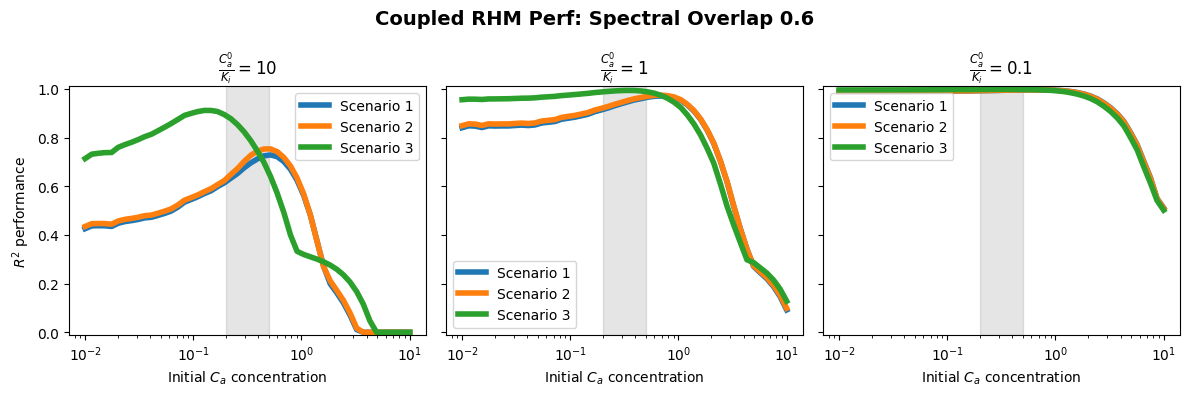

In [14]:
# Exploratory plot: CRMM1 (first-order kinetics, no ANN) out-of-sample R^2
# vs. initial Ca concentration, spectral overlap 0.6.
fig, axs = plt.subplots(1, 3, figsize = (12, 4), sharex = True, sharey = True)

for k in range(len(scenario_list)):
    couple_dir = "Coupled Performance/Mechanistic model - version 1/" + scenario_list[k]
    couple_file_dict = full_coupled_phenom_dict[scenario_list[k]]
    
    C6_performance_list = couple_file_dict["0.6"]

    C6_unique_dict = {}
    for i in range(len(C6_performance_list)):
        name = C6_performance_list[i]
        k1 = float(name.split("_")[1])
        k2 = float(name.split("_")[2])
        ky = tuple([k1, k2])

        if ky not in list(C6_unique_dict.keys()):
            C6_unique_dict[ky] = []

        filepath = os.path.join(couple_dir, name)
        with open(filepath, "rb") as f:
            data = np.array(pickle.load(f)["conc_perf"])[:,0]

        C6_unique_dict[ky].append(data)
        
    row_title = [r"$\frac{C_a^0}{K_i} = 10$", r"$\frac{C_a^0}{K_i} = 1$", r"$\frac{C_a^0}{K_i} = 0.1$"]

    for a in list(C6_unique_dict.keys()):
        xind = int(2 + np.log10(a[0]/5))

        data = np.mean(np.array(C6_unique_dict[a]), axis = 0)

        axs[xind].plot(C1_range, data, label = scenario_list[k], linewidth = 4)
        axs[xind].legend()
        axs[xind].set_xscale("log")
        if k == 0:
            axs[xind].axvspan(0.2, 0.5, color = "k", alpha = 0.1)
        axs[xind].set_ylim([-0.01, 1.01])
        axs[xind].set_xlabel("Initial $C_a$ concentration")
        axs[xind].set_title(row_title[xind])
        if xind == 0:
            axs[xind].set_ylabel("$R^2$ performance")
        
fig.suptitle("Coupled RHM Perf: Spectral Overlap 0.6", fontweight = "bold", fontsize = 14)
plt.tight_layout()

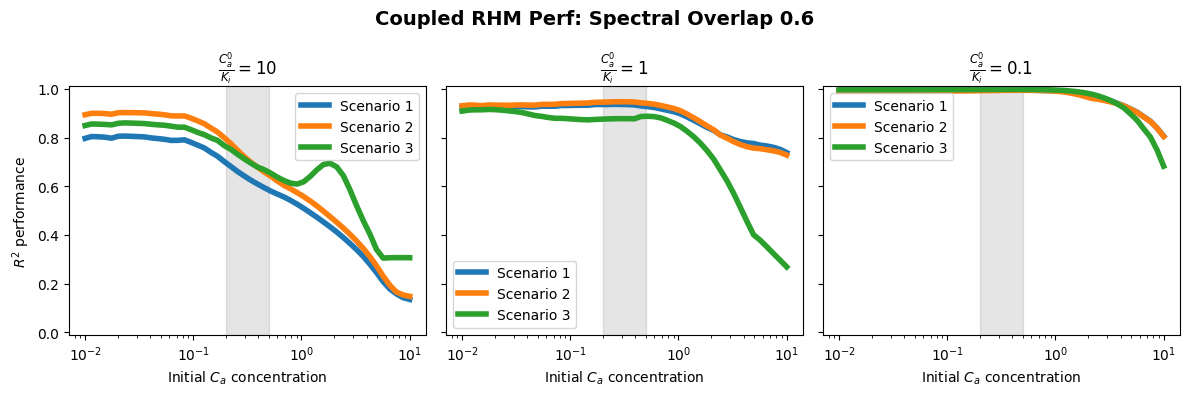

In [15]:
# Exploratory plot: CRMM2 (Michaelis-Menten kinetics, no ANN) out-of-sample
# R^2 vs. initial Ca concentration, spectral overlap 0.6. Uses the CRMM1-
# built full_coupled_phenom_dict file-name index but reads from the
# "version 2" directory (same filenames, different model results).
fig, axs = plt.subplots(1, 3, figsize = (12, 4), sharex = True, sharey = True)

for k in range(len(scenario_list)):
    couple_dir = "Coupled Performance/Mechanistic model - version 2/" + scenario_list[k]
    couple_file_dict = full_coupled_phenom_dict[scenario_list[k]]
    
    C6_performance_list = couple_file_dict["0.6"]

    C6_unique_dict = {}
    for i in range(len(C6_performance_list)):
        name = C6_performance_list[i]
        k1 = float(name.split("_")[1])
        k2 = float(name.split("_")[2])
        ky = tuple([k1, k2])

        if ky not in list(C6_unique_dict.keys()):
            C6_unique_dict[ky] = []

        filepath = os.path.join(couple_dir, name)
        with open(filepath, "rb") as f:
            data = np.array(pickle.load(f)["conc_perf"])[:,0]

        C6_unique_dict[ky].append(data)
        
    row_title = [r"$\frac{C_a^0}{K_i} = 10$", r"$\frac{C_a^0}{K_i} = 1$", r"$\frac{C_a^0}{K_i} = 0.1$"]

    for a in list(C6_unique_dict.keys()):
        xind = int(2 + np.log10(a[0]/5))

        data = np.mean(np.array(C6_unique_dict[a]), axis = 0)

        axs[xind].plot(C1_range, data, label = scenario_list[k], linewidth = 4)
        axs[xind].legend()
        axs[xind].set_xscale("log")
        if k == 0:
            axs[xind].axvspan(0.2, 0.5, color = "k", alpha = 0.1)
        axs[xind].set_ylim([-0.01, 1.01])
        axs[xind].set_xlabel("Initial $C_a$ concentration")
        axs[xind].set_title(row_title[xind])
        if xind == 0:
            axs[xind].set_ylabel("$R^2$ performance")
        
fig.suptitle("Coupled RHM Perf: Spectral Overlap 0.6", fontweight = "bold", fontsize = 14)
plt.tight_layout()

# Image Generation for manuscript

## Figure 3: CRHM vs IRHM-SVD

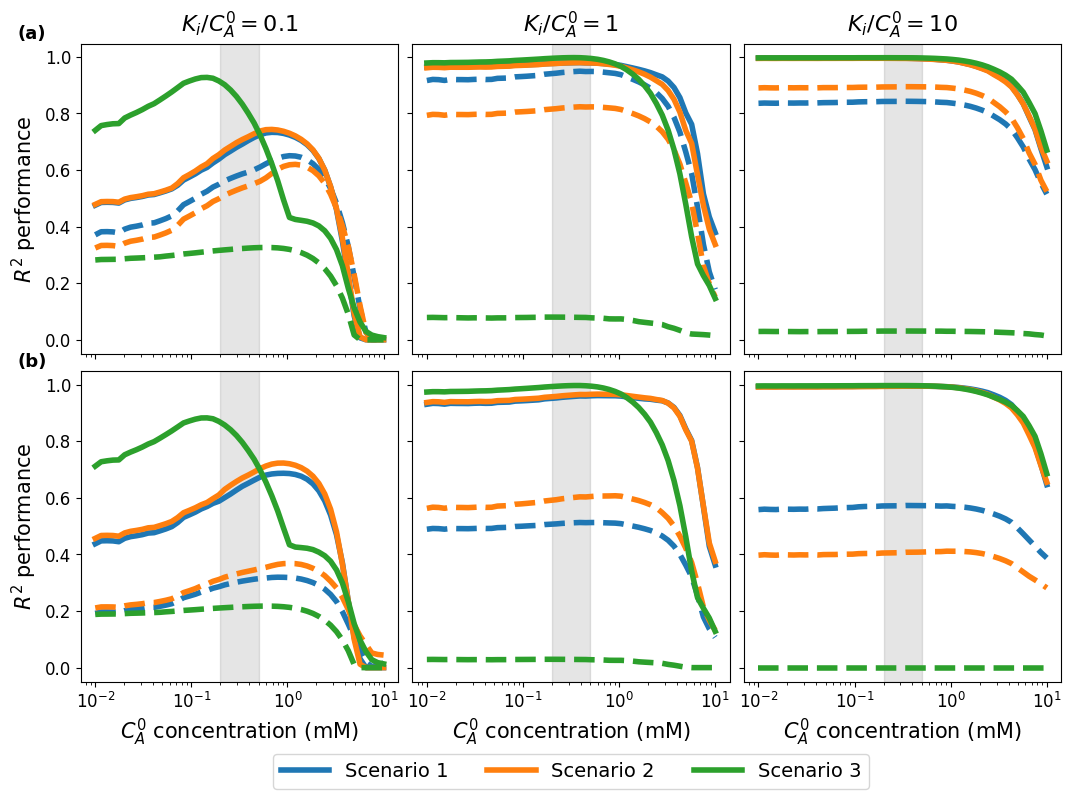

In [16]:
# ---- Manuscript Figure 3: CRHM vs. IRHM-SVD ----
# 2 (spectral overlap) x 3 (inhibition strength) grid of panels, each
# overlaying the CRHM (solid) and IRHM-SVD (dashed) R^2-vs-concentration
# curves for all three scenarios. Built with a manual GridSpec (extra row
# for a shared legend, extra column for row titles) rather than
# plt.subplots, so row/column labels and a single shared legend can be
# placed precisely in figure coordinates.
# ── Global font size ─────────────────────────────────────────────────────────
FONT_SIZE = 11
plt.rcParams.update({
    "font.size":        FONT_SIZE,
    "axes.titlesize":   FONT_SIZE,
    "axes.labelsize":   FONT_SIZE,
    "xtick.labelsize":  FONT_SIZE + 1,
    "ytick.labelsize":  FONT_SIZE + 1,
    "legend.fontsize":  FONT_SIZE + 1,
})

# ── Layout constants ──────────────────────────────────────────────────────────
spc_list   = ["0.2", "0.6"]
row_titles = [
    r"$K_i/C_A^0 = 0.1$",
    r"$K_i/C_A^0 = 1$",
    r"$K_i/C_A^0 = 10$",
]
colors = ['tab:blue', 'tab:orange', 'tab:green']
fig_labels = ["(a)", "(b)"]
NROWS, NCOLS = 2, 3

# ── Figure and GridSpec ───────────────────────────────────────────────────────
# Structure:  NROWS data rows  +  1 legend row
#             1 row-title col  +  NCOLS data cols
fig = plt.figure(figsize=(13, 9))
gs = fig.add_gridspec(
    nrows=NROWS + 1,
    ncols=NCOLS + 1,
    height_ratios=[1] * NROWS + [0.12],
    width_ratios=[0.04] + [1] * NCOLS,   # narrow placeholder col for row titles
    hspace=0.08,
    wspace=0.06,
)

# ── Data axes ────────────────────────────────────────────────────────────────
axs = np.empty((NROWS, NCOLS), dtype=object)
shared_x = shared_y = None

for row in range(NROWS):
    for col in range(NCOLS):
        ax = fig.add_subplot(
            gs[row, col + 1],
            sharex=shared_x,
            sharey=shared_y,
        )
        axs[row, col] = ax
        if shared_x is None:
            shared_x = ax
            shared_y = ax
        if row < NROWS - 1:
            plt.setp(ax.get_xticklabels(), visible=False)
        if col > 0:
            plt.setp(ax.get_yticklabels(), visible=False)

# ── Row titles: placed via fig.text in figure coordinates ────────────────────
# Get the vertical midpoint of each row's axes in figure coords, then place
# text just to the left of the leftmost data column.
# Axis positions aren't finalized until a draw pass happens; force one here
# so the get_position() calls below return real (not default) coordinates.
fig.canvas.draw()  # needed so get_position() returns real values

for row, title in enumerate(row_titles):
    ax = axs[0, row]
    pos = ax.get_position()                      # Bbox in figure coords
    y_mid = pos.y1 + 0.02               # vertical centre of row
    x_left = (pos.x0 + pos.x1)/2                     # nudge left of the data panel

    fig.text(x_left, y_mid, title,
             ha="center", va="center",
             fontsize=16)

# ── Figure labels (a) / (b) in top-left corner of top panels ─────────────────
for col, label in enumerate(fig_labels):
    axs[0, col].text(-0.2, 1.06, label,
                     transform=axs[col, 0].transAxes,
                     fontsize=13, fontweight="bold",
                     va="top", ha="left")
# ── Axis labels ───────────────────────────────────────────────────────────────
for row in range(NROWS):
    axs[row, 0].set_ylabel("$R^2$ performance", fontsize = 15)

for col in range(NCOLS):
    axs[NROWS-1, col].set_xlabel("$C^0_A$ concentration (mM)", fontsize = 15)

# ── Data loading and plotting ─────────────────────────────────────────────────
handles, labels = [], []

# Main data loop: for each (spectral overlap row, scenario), load and
# average the CRHM and IRHM-SVD R^2 curves for every (Ki1, Ki2) condition,
# downsample IRHM-SVD's 500-point Scenario-3 curves back to 50 points, and
# plot both onto the shared panel for that (overlap, inhibition-strength)
# cell.
for l in range(NROWS):
    key = spc_list[l]
    for k in range(len(scenario_list)):
        couple_dir = "Coupled Performance/Hybrid Model/" + scenario_list[k] + "/(322)_ANN"
        C2_performance_list = full_coupled_dict[scenario_list[k]][key]
        C2_unique_dict = {}
        for name in C2_performance_list:
            k1 = float(name.split("_")[1])
            k2 = float(name.split("_")[2])
            ky = (k1, k2)
            C2_unique_dict.setdefault(ky, [])
            with open(os.path.join(couple_dir, name), "rb") as f:
                C2_unique_dict[ky].append(
                    np.array(pickle.load(f)["conc_perf"])[:, 0])

        iterative_dir = "Iterative Performance/SVD_init/" + scenario_list[k] + "/(322)_ANN"
        I2_performance_list = full_iterative_dict[scenario_list[k]][key]
        I2_unique_dict = {}
        for name in I2_performance_list:
            k1 = float(name.split("_")[1])
            k2 = float(name.split("_")[2])
            ky = (k1, k2)
            I2_unique_dict.setdefault(ky, [])
            with open(os.path.join(iterative_dir, name), "rb") as f:
                I2_unique_dict[ky].append(
                    np.array(pickle.load(f)["conc_perf"])[:, 0])

        for a in C2_unique_dict:
            xind = int(2 + np.log10(a[0] / 5))
            C_data = np.mean(np.array(C2_unique_dict[a]), axis=0)
            I_data = np.mean(np.array(I2_unique_dict[a]), axis=0)
            if len(I_data) == 500:
                I_data = I_data[::10]

            ax = axs[l, xind]
            line, = ax.plot(C1_range, C_data, color = colors[k],
                            label=scenario_list[k], linewidth=4)
            ax.plot(C1_range, I_data, "--", color = colors[k],
                            label=scenario_list[k], linewidth=4)
            ax.set_xscale("log")
            #ax.set_ylim([-1.05, 1.05])

            if k == 2:
                ax.axvspan(0.2, 0.5, color="k", alpha=0.1)

            if l == 0 and scenario_list[k] not in labels:
                handles.append(line)
                labels.append(scenario_list[k])

# ── Legend: fig.legend anchored below the bottom data panels ─────────────────
# Re-draw so axis positions are finalised before we compute coordinates
# Re-draw so the finalized bottom-row axis positions can be used to place a
# single shared legend centered below the whole grid.
fig.canvas.draw()

bottom_pos = axs[NROWS - 1, 0].get_position()
x_centre   = (axs[NROWS - 1, 0].get_position().x0 +
               axs[NROWS - 1, NCOLS - 1].get_position().x1) / 2
y_legend   = bottom_pos.y0 - 0.1   # clear below x-axis tick labels + label

fig.legend(
    handles, labels,
    loc="center",
    ncol=len(scenario_list),
    frameon=True,
    handlelength=2.5,
    bbox_to_anchor=(x_centre, y_legend),
    bbox_transform=fig.transFigure, fontsize = 14
)

plt.savefig("Coup_Iter_SVD_v3.svg", dpi = 300, bbox_inches="tight")
plt.show()

## Figure 4: CRHM vs IRHM-SIMPLISMA

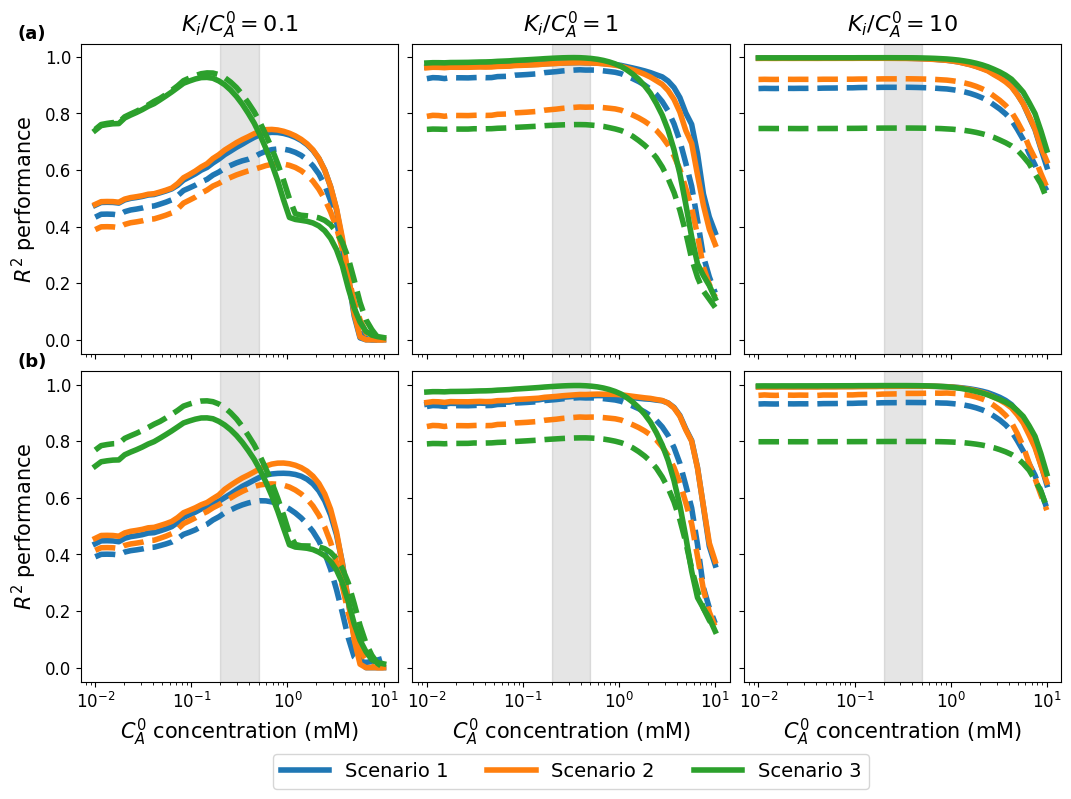

In [17]:
# ---- Manuscript Figure 4: CRHM vs. IRHM-SIMPLISMA ----
# Identical layout/logic to the Figure 3 cell above, with IRHM-SIMPLISMA
# results substituted for IRHM-SVD.
# ── Global font size ─────────────────────────────────────────────────────────
FONT_SIZE = 11
plt.rcParams.update({
    "font.size":        FONT_SIZE,
    "axes.titlesize":   FONT_SIZE,
    "axes.labelsize":   FONT_SIZE,
    "xtick.labelsize":  FONT_SIZE + 1,
    "ytick.labelsize":  FONT_SIZE + 1,
    "legend.fontsize":  FONT_SIZE + 1,
})

# ── Layout constants ──────────────────────────────────────────────────────────
spc_list   = ["0.2", "0.6"]
row_titles = [
    r"$K_i/C_A^0 = 0.1$",
    r"$K_i/C_A^0 = 1$",
    r"$K_i/C_A^0 = 10$",
]
fig_labels = ["(a)", "(b)"]
NROWS, NCOLS = 2, 3

# ── Figure and GridSpec ───────────────────────────────────────────────────────
# Structure:  NROWS data rows  +  1 legend row
#             1 row-title col  +  NCOLS data cols
fig = plt.figure(figsize=(13, 9))
gs = fig.add_gridspec(
    nrows=NROWS + 1,
    ncols=NCOLS + 1,
    height_ratios=[1] * NROWS + [0.12],
    width_ratios=[0.04] + [1] * NCOLS,   # narrow placeholder col for row titles
    hspace=0.08,
    wspace=0.06,
)

# ── Data axes ────────────────────────────────────────────────────────────────
axs = np.empty((NROWS, NCOLS), dtype=object)
shared_x = shared_y = None

for row in range(NROWS):
    for col in range(NCOLS):
        ax = fig.add_subplot(
            gs[row, col + 1],
            sharex=shared_x,
            sharey=shared_y,
        )
        axs[row, col] = ax
        if shared_x is None:
            shared_x = ax
            shared_y = ax
        if row < NROWS - 1:
            plt.setp(ax.get_xticklabels(), visible=False)
        if col > 0:
            plt.setp(ax.get_yticklabels(), visible=False)

# ── Row titles: placed via fig.text in figure coordinates ────────────────────
# Get the vertical midpoint of each row's axes in figure coords, then place
# text just to the left of the leftmost data column.
# Axis positions aren't finalized until a draw pass happens; force one here
# so the get_position() calls below return real (not default) coordinates.
fig.canvas.draw()  # needed so get_position() returns real values

for row, title in enumerate(row_titles):
    ax = axs[0, row]
    pos = ax.get_position()                      # Bbox in figure coords
    y_mid = pos.y1 + 0.02               # vertical centre of row
    x_left = (pos.x0 + pos.x1)/2                     # nudge left of the data panel

    fig.text(x_left, y_mid, title,
             ha="center", va="center",
             fontsize=16)

# ── Figure labels (a) / (b) in top-left corner of top panels ─────────────────
for col, label in enumerate(fig_labels):
    axs[0, col].text(-0.2, 1.06, label,
                     transform=axs[col, 0].transAxes,
                     fontsize=13, fontweight="bold",
                     va="top", ha="left")

# ── Axis labels ───────────────────────────────────────────────────────────────
for row in range(NROWS):
    axs[row, 0].set_ylabel("$R^2$ performance", fontsize = 15)

for col in range(NCOLS):
    axs[NROWS-1, col].set_xlabel("$C^0_A$ concentration (mM)", fontsize = 15)

# ── Data loading and plotting ─────────────────────────────────────────────────
handles, labels = [], []

# Main data loop: for each (spectral overlap row, scenario), load and
# average the CRHM and IRHM-SIMPLISMA R^2 curves for every (Ki1, Ki2)
# condition, downsample the 500-point Scenario-3 curves back to 50 points,
# and plot both onto the shared panel.
for l in range(NROWS):
    key = spc_list[l]
    for k in range(len(scenario_list)):
        couple_dir = "Coupled Performance/Hybrid model/" + scenario_list[k] + "/(322)_ANN"
        C2_performance_list = full_coupled_dict[scenario_list[k]][key]
        C2_unique_dict = {}
        for name in C2_performance_list:
            k1 = float(name.split("_")[1])
            k2 = float(name.split("_")[2])
            ky = (k1, k2)
            C2_unique_dict.setdefault(ky, [])
            with open(os.path.join(couple_dir, name), "rb") as f:
                C2_unique_dict[ky].append(
                    np.array(pickle.load(f)["conc_perf"])[:, 0])

        iterative_dir = "Iterative Performance/SIMPLISMA_init/" + scenario_list[k] + "/(322)_ANN"
        I2_performance_list = full_iterative_dict[scenario_list[k]][key]
        I2_unique_dict = {}
        for name in I2_performance_list:
            k1 = float(name.split("_")[1])
            k2 = float(name.split("_")[2])
            ky = (k1, k2)
            I2_unique_dict.setdefault(ky, [])
            with open(os.path.join(iterative_dir, name), "rb") as f:
                I2_unique_dict[ky].append(
                    np.array(pickle.load(f)["conc_perf"])[:, 0])

        for a in C2_unique_dict:
            xind = int(2 + np.log10(a[0] / 5))
            C_data = np.mean(np.array(C2_unique_dict[a]), axis=0)
            I_data = np.mean(np.array(I2_unique_dict[a]), axis=0)
            if len(I_data) == 500:
                I_data = I_data[::10]

            ax = axs[l, xind]
            line, = ax.plot(C1_range, C_data, color = colors[k],
                            label=scenario_list[k], linewidth=4)
            ax.plot(C1_range, I_data, "--", color = colors[k],
                            label=scenario_list[k], linewidth=4)
            ax.set_xscale("log")
            #ax.set_ylim([-1.05, 1.05])

            if k == 2:
                ax.axvspan(0.2, 0.5, color="k", alpha=0.1)
                #ax.axhline(0, linestyle="--", color="k", linewidth=2)

            if l == 0 and scenario_list[k] not in labels:
                handles.append(line)
                labels.append(scenario_list[k])

# ── Legend: fig.legend anchored below the bottom data panels ─────────────────
# Re-draw so axis positions are finalised before we compute coordinates
# Re-draw so the finalized bottom-row axis positions can be used to place a
# single shared legend centered below the whole grid.
fig.canvas.draw()

bottom_pos = axs[NROWS - 1, 0].get_position()
x_centre   = (axs[NROWS - 1, 0].get_position().x0 +
               axs[NROWS - 1, NCOLS - 1].get_position().x1) / 2
y_legend   = bottom_pos.y0 - 0.1   # clear below x-axis tick labels + label

fig.legend(
    handles, labels,
    loc="center",
    ncol=len(scenario_list),
    frameon=True,
    handlelength=2.5,
    bbox_to_anchor=(x_centre, y_legend),
    bbox_transform=fig.transFigure, fontsize = 14
)

plt.savefig("Coup_Iter_SML_v3.svg", dpi = 300, bbox_inches="tight")
plt.show()

## Figure 5: CRHM vs CRMM

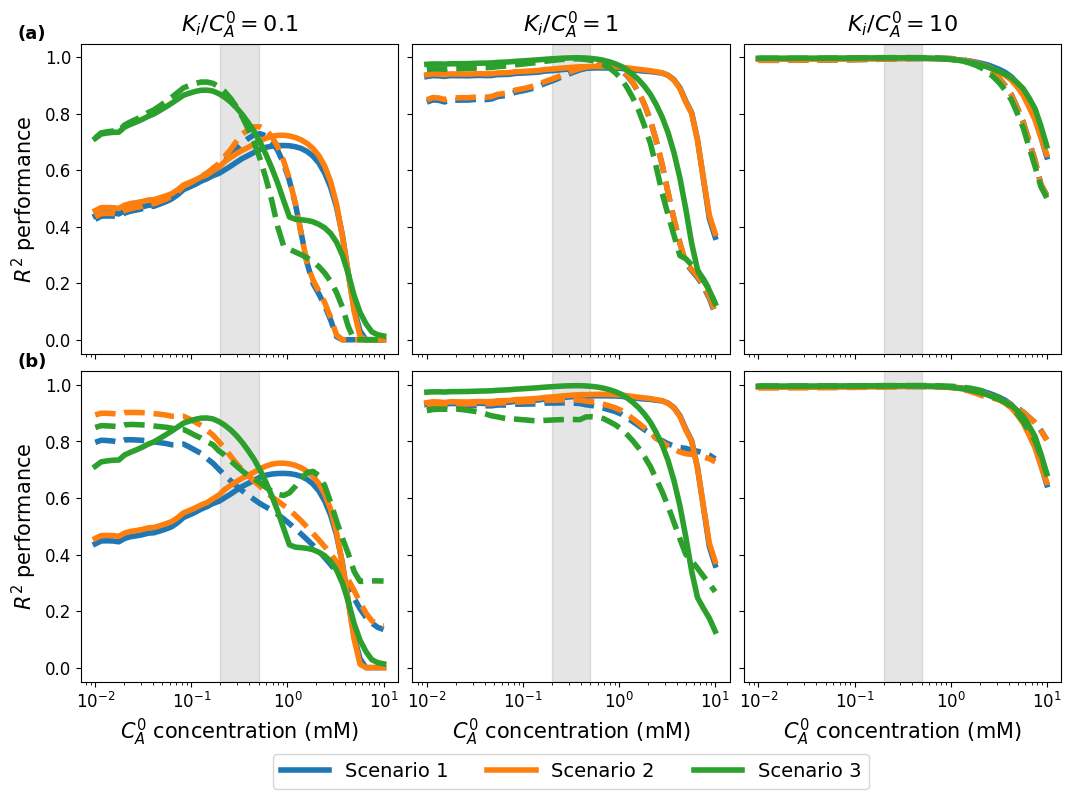

In [18]:
# ---- Manuscript Figure 5: CRHM vs. CRMM1/CRMM2 (mechanistic baselines) ----
# 2-row grid: row (a) overlays CRHM (solid) against CRMM1 (dashed,
# first-order kinetics); row (b) overlays CRHM against CRMM2 (dashed,
# Michaelis-Menten kinetics). Only spectral overlap 0.6 is shown here
# (unlike Figures 3-4, which show both overlap levels as the two rows).
# Same manual-GridSpec + shared-legend approach as Figures 3-4.
# ── Global font size ─────────────────────────────────────────────────────────
FONT_SIZE = 11
plt.rcParams.update({
    "font.size":        FONT_SIZE,
    "axes.titlesize":   FONT_SIZE,
    "axes.labelsize":   FONT_SIZE,
    "xtick.labelsize":  FONT_SIZE + 1,
    "ytick.labelsize":  FONT_SIZE + 1,
    "legend.fontsize":  FONT_SIZE + 1,
})

# ── Layout constants ──────────────────────────────────────────────────────────
spc_list   = ["0.2", "0.6"]
row_titles = [
    r"$K_i/C_A^0 = 0.1$",
    r"$K_i/C_A^0 = 1$",
    r"$K_i/C_A^0 = 10$",
]
fig_labels = ["(a)", "(b)"]
NROWS, NCOLS = 2, 3

# ── Figure and GridSpec ───────────────────────────────────────────────────────
# Structure:  NROWS data rows  +  1 legend row
#             1 row-title col  +  NCOLS data cols
fig = plt.figure(figsize=(13, 9))
gs = fig.add_gridspec(
    nrows=NROWS + 1,
    ncols=NCOLS + 1,
    height_ratios=[1] * NROWS + [0.12],
    width_ratios=[0.04] + [1] * NCOLS,   # narrow placeholder col for row titles
    hspace=0.08,
    wspace=0.06,
)

# ── Data axes ────────────────────────────────────────────────────────────────
axs = np.empty((NROWS, NCOLS), dtype=object)
shared_x = shared_y = None

for row in range(NROWS):
    for col in range(NCOLS):
        ax = fig.add_subplot(
            gs[row, col + 1],
            sharex=shared_x,
            sharey=shared_y,
        )
        axs[row, col] = ax
        if shared_x is None:
            shared_x = ax
            shared_y = ax
        if row < NROWS - 1:
            plt.setp(ax.get_xticklabels(), visible=False)
        if col > 0:
            plt.setp(ax.get_yticklabels(), visible=False)

# ── Row titles: placed via fig.text in figure coordinates ────────────────────
# Get the vertical midpoint of each row's axes in figure coords, then place
# text just to the left of the leftmost data column.
# Axis positions aren't finalized until a draw pass happens; force one here
# so the get_position() calls below return real (not default) coordinates.
fig.canvas.draw()  # needed so get_position() returns real values

for row, title in enumerate(row_titles):
    ax = axs[0, row]
    pos = ax.get_position()                      # Bbox in figure coords
    y_mid = pos.y1 + 0.02               # vertical centre of row
    x_left = (pos.x0 + pos.x1)/2                     # nudge left of the data panel

    fig.text(x_left, y_mid, title,
             ha="center", va="center",
             fontsize=16)

# ── Figure labels (a) / (b) in top-left corner of top panels ─────────────────
for col, label in enumerate(fig_labels):
    axs[0, col].text(-0.2, 1.06, label,
                     transform=axs[col, 0].transAxes,
                     fontsize=13, fontweight="bold",
                     va="top", ha="left")

# ── Axis labels ───────────────────────────────────────────────────────────────
for row in range(NROWS):
    axs[row, 0].set_ylabel("$R^2$ performance", fontsize = 15)

for col in range(NCOLS):
    axs[NROWS-1, col].set_xlabel("$C^0_A$ concentration (mM)", fontsize = 15)

# ── Data loading and plotting ─────────────────────────────────────────────────
handles, labels = [], []

for k in range(len(scenario_list)):
    couple_dir = "Coupled Performance/Hybrid model/" + scenario_list[k] + "/(322)_ANN"
    C2_performance_list = full_coupled_dict[scenario_list[k]]["0.6"]
    C2_unique_dict = {}
    for name in C2_performance_list:
        k1 = float(name.split("_")[1])
        k2 = float(name.split("_")[2])
        ky = (k1, k2)
        C2_unique_dict.setdefault(ky, [])
        with open(os.path.join(couple_dir, name), "rb") as f:
            C2_unique_dict[ky].append(
                np.array(pickle.load(f)["conc_perf"])[:, 0])

    # Row (a): load CRHM results plus CRMM1 results for every (Ki1, Ki2)
    # condition at spectral overlap 0.6, average, and plot both (solid/dashed)
    # onto the top row of panels.
    couple_phenom_dir = "Coupled Performance/Mechanistic model - version 1/" + scenario_list[k]
    CP6_performance_list = full_coupled_phenom_dict[scenario_list[k]]["0.6"]
    
    CP6_unique_dict = {}
    for i in range(len(CP6_performance_list)):
        name = CP6_performance_list[i]
        k1 = float(name.split("_")[1])
        k2 = float(name.split("_")[2])
        ky = tuple([k1, k2])
        if ky not in list(CP6_unique_dict.keys()):
            CP6_unique_dict[ky] = []
        filepath = os.path.join(couple_phenom_dir, name)
        with open(filepath, "rb") as f:
            data = np.array(pickle.load(f)["conc_perf"])[:,0]
        CP6_unique_dict[ky].append(data)

    for a in C2_unique_dict:
        xind = int(2 + np.log10(a[0] / 5))
        C_data = np.mean(np.array(C2_unique_dict[a]), axis=0)
        I_data = np.mean(np.array(CP6_unique_dict[a]), axis=0)

        ax = axs[0, xind]
        line, = ax.plot(C1_range, C_data, color = colors[k],
                        label=scenario_list[k], linewidth=4)
        ax.plot(C1_range, I_data, "--", color = colors[k],
                        label=scenario_list[k], linewidth=4)
        ax.set_xscale("log")
        #ax.set_ylim([-1.05, 1.05])

        if k == 2:
            ax.axvspan(0.2, 0.5, color="k", alpha=0.1)

        if scenario_list[k] not in labels:
            handles.append(line)
            labels.append(scenario_list[k])
    
for k in range(len(scenario_list)):
    couple_dir = "Coupled Performance/Hybrid model/" + scenario_list[k] + "/(322)_ANN"
    C2_performance_list = full_coupled_dict[scenario_list[k]]["0.6"]
    C2_unique_dict = {}
    for name in C2_performance_list:
        k1 = float(name.split("_")[1])
        k2 = float(name.split("_")[2])
        ky = (k1, k2)
        C2_unique_dict.setdefault(ky, [])
        with open(os.path.join(couple_dir, name), "rb") as f:
            C2_unique_dict[ky].append(
                np.array(pickle.load(f)["conc_perf"])[:, 0])

    # Row (b): same as above, but comparing CRHM against CRMM2 instead of CRMM1.
    couple_phenom_dir = "Coupled Performance/Mechanistic model - version 2/" + scenario_list[k]
    CP6_performance_list = full_coupled_phenom_dict[scenario_list[k]]["0.6"]
    
    CP6_unique_dict = {}
    for i in range(len(CP6_performance_list)):
        name = CP6_performance_list[i]
        k1 = float(name.split("_")[1])
        k2 = float(name.split("_")[2])
        ky = tuple([k1, k2])
        if ky not in list(CP6_unique_dict.keys()):
            CP6_unique_dict[ky] = []
        filepath = os.path.join(couple_phenom_dir, name)
        with open(filepath, "rb") as f:
            data = np.array(pickle.load(f)["conc_perf"])[:,0]
        CP6_unique_dict[ky].append(data)

    for a in C2_unique_dict:
        xind = int(2 + np.log10(a[0] / 5))
        C_data = np.mean(np.array(C2_unique_dict[a]), axis=0)
        I_data = np.mean(np.array(CP6_unique_dict[a]), axis=0)

        ax = axs[1, xind]
        line, = ax.plot(C1_range, C_data, color = colors[k],
                        label=scenario_list[k], linewidth=4)
        ax.plot(C1_range, I_data, "--", color = colors[k],
                        label=scenario_list[k], linewidth=4)
        ax.set_xscale("log")
        #ax.set_ylim([-1.05, 1.05])

        if k == 2:
            ax.axvspan(0.2, 0.5, color="k", alpha=0.1)

# ── Legend: fig.legend anchored below the bottom data panels ─────────────────
# Re-draw so axis positions are finalised before we compute coordinates
# Re-draw so the finalized bottom-row axis positions can be used to place a
# single shared legend centered below the whole grid.
fig.canvas.draw()

bottom_pos = axs[NROWS - 1, 0].get_position()
x_centre   = (axs[NROWS - 1, 0].get_position().x0 +
               axs[NROWS - 1, NCOLS - 1].get_position().x1) / 2
y_legend   = bottom_pos.y0 - 0.1   # clear below x-axis tick labels + label

fig.legend(
    handles, labels,
    loc="center",
    ncol=len(scenario_list),
    frameon=True,
    handlelength=2.5,
    bbox_to_anchor=(x_centre, y_legend),
    bbox_transform=fig.transFigure, fontsize = 14
)

plt.savefig("Coup_HM_PM_v3.svg", dpi = 300, bbox_inches="tight")
plt.show()